## 패키지 선언

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader


## Conv2d 실습

### input channel = 1

In [ ]:
# 테스트 입력 텐서 생성
test_tensor = torch.rand(1, 1, 5, 5) # Batch size, Channel, Height, Width
print(test_tensor.size())
print(test_tensor)

torch.Size([1, 1, 5, 5])
tensor([[[[0.5407, 0.0952, 0.5324, 0.2823, 0.3159],
          [0.5846, 0.4685, 0.5068, 0.7416, 0.7566],
          [0.2255, 0.1448, 0.9428, 0.8236, 0.8434],
          [0.9691, 0.9427, 0.1005, 0.1580, 0.0094],
          [0.4977, 0.2194, 0.3054, 0.5320, 0.5810]]]])


In [ ]:
class testModel_channel1 (nn.Module):
  def __init__(self):
    super(testModel_channel1, self).__init__()

    self.conv = nn.Conv2d(in_channels = 1, out_channels = 1, kernel_size = 3)

  def forward(self, x):

    # run code
    y = self.conv(x)

    return y

In [ ]:
model = testModel_channel1()
out = model(test_tensor)
print(out.size())
print(out)

torch.Size([1, 1, 3, 3])
tensor([[[[-0.0917,  0.0526, -0.0194],
          [ 0.0076, -0.1279, -0.2204],
          [-0.0610, -0.0572, -0.1585]]]], grad_fn=<ConvolutionBackward0>)


### input channel = 3, output channel = 64

In [ ]:
test_tensor = torch.rand(1, 3, 32, 32)

In [ ]:
class testModel_channel3 (nn.Module):
  def __init__(self):
    super(testModel_channel3, self).__init__()

    self.conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3)

  def forward(self, x):

    y = self.conv(x)

    return y

In [ ]:
model = testModel_channel3()
out = model(test_tensor)
print(out.size())

torch.Size([1, 64, 30, 30])


### 3 Convolution layer
####in_channel = 1, out_channel = 32
####in_channel = 32, out_channel = 64
####in_channel = 64, out_channel = 128

In [ ]:
test_tensor = torch.rand(1, 1, 32, 32)

In [ ]:
class testModel_layer3 (nn.Module):
  def __init__(self):
    super(testModel_layer3, self).__init__()

    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size=3)
    self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size=3)


  def forward(self, x):

    y = self.conv1(x)
    y = self.conv2(y)
    y = self.conv3(y)

    return y

In [ ]:
model = testModel_layer3()
out = model(test_tensor)
print(out.size())

torch.Size([1, 128, 26, 26])


## Dataset 선언

In [ ]:
# Training dataset 다운로드
cifar10_train = dataset.CIFAR10(root = "./", # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
cifar10_test = dataset.CIFAR10(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 170498071/170498071 [00:05<00:00, 29963136.53it/s]


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


## CIFAR10 데이터셋 형상 확인

50000
torch.Size([3, 32, 32])
9


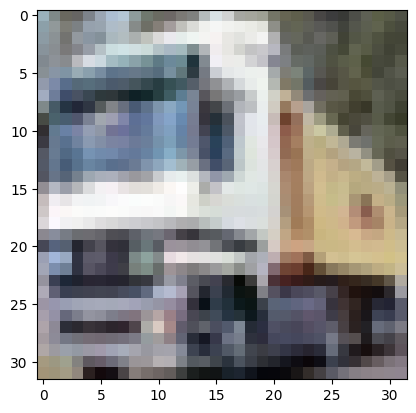

In [ ]:
from matplotlib import pyplot as plt
print(len(cifar10_train))     # training dataset 개수 확인

first_data = cifar10_train[1]
print(first_data[0].shape)  # 두번째 data의 형상 확인
print(first_data[1])        # 두번째 data의 정답 확인


plt.imshow(first_data[0].permute(1, 2, 0))
plt.show()

## CNN 모델 정의

In [ ]:
class CNN (nn.Module):
  def __init__ (self):
    super(CNN, self).__init__()
    #convolution code
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 6, kernel_size = 5, stride = 1, padding = 0)
    self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size = 5, stride = 1, padding = 0)

    self.relu = nn.ReLU()

    self.MaxPool2d = nn.MaxPool2d(kernel_size = 2, stride = 2)

    self.mlp1 = nn.Linear(400, 120)
    self.mlp2 = nn.Linear(120, 84)
    self.mlp3 = nn.Linear(84, 10)

  def forward(self, x):
    #cnn code
    y = self.relu(self.conv1(x))
    y = self.MaxPool2d(y)
    y = self.relu(self.conv2(y))
    y = self.MaxPool2d(y)
    y = y.reshape(-1, 5*5*16)

    #mlp code
    y = self.relu(self.mlp1(y))
    y = self.relu(self.mlp2(y))
    y = self.mlp3(y)

    return y

## Hyper-parameters 지정

In [ ]:
batch_size = 100
learning_rate = 0.1
training_epochs = 30
loss_function = nn.CrossEntropyLoss()
network = CNN()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)
data_loader = DataLoader(dataset=cifar10_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [ ]:
network = network.to('cuda:0')
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    img = img.to('cuda:0')
    label = label.to('cuda:0')

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 2.286520
Epoch: 2 Loss = 2.152683
Epoch: 3 Loss = 1.955513
Epoch: 4 Loss = 1.824303
Epoch: 5 Loss = 1.707945
Epoch: 6 Loss = 1.637897
Epoch: 7 Loss = 1.594522
Epoch: 8 Loss = 1.550602
Epoch: 9 Loss = 1.514044
Epoch: 10 Loss = 1.474453
Epoch: 11 Loss = 1.439363
Epoch: 12 Loss = 1.411697
Epoch: 13 Loss = 1.377877
Epoch: 14 Loss = 1.236509
Epoch: 15 Loss = 1.192396
Learning finished


## 학습이 완료된 모델을 이용해 정답률 확인

In [ ]:
network = network.to('cpu')
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = torch.tensor(np.transpose(cifar10_test.data, (0, 3, 1, 2)))/255.
  label_test = torch.tensor(cifar10_test.targets)

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.5235000252723694


## CNN 모델 정의2 (더 높은 정확도를 가지는 LeNet-5)

In [ ]:
class CNN (nn.Module):
  def __init__ (self):
    super(CNN, self).__init__()
    #convolution code
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 64, kernel_size = 5, stride = 1, padding = 0)
    self.conv2 = nn.Conv2d(in_channels = 64, out_channels = 16, kernel_size = 5, stride = 1, padding = 0)

    self.relu = nn.ReLU()

    self.MaxPool2d = nn.MaxPool2d(kernel_size = 2, stride = 2)

    self.mlp1 = nn.Linear(400, 120)
    self.mlp2 = nn.Linear(120, 84)
    self.mlp3 = nn.Linear(84, 10)

  def forward(self, x):
    #cnn code
    y = self.relu(self.conv1(x))
    y = self.MaxPool2d(y)
    y = self.relu(self.conv2(y))
    y = self.MaxPool2d(y)
    y = y.reshape(-1, 5*5*16)

    #mlp code
    y = self.relu(self.mlp1(y))
    y = self.relu(self.mlp2(y))
    y = self.mlp3(y)

    return y

## Hyper-parameters 지정

In [ ]:
batch_size = 100
learning_rate = 0.1
training_epochs = 200
loss_function = nn.CrossEntropyLoss()
network = CNN()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [75, 150], gamma=0.5)

data_loader = DataLoader(dataset=cifar10_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [ ]:
network = network.to('cuda:0')
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    img = img.to('cuda:0')
    label = label.to('cuda:0')

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))
  scheduler.step()

print('Learning finished')

/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 1 Loss = 2.238816
Epoch: 2 Loss = 2.045552
Epoch: 3 Loss = 1.806101
Epoch: 4 Loss = 1.604604
Epoch: 5 Loss = 1.443598
Epoch: 6 Loss = 1.319657
Epoch: 7 Loss = 1.235401
Epoch: 8 Loss = 1.158600
Epoch: 9 Loss = 1.094528
Epoch: 10 Loss = 1.041644
Epoch: 11 Loss = 0.983396
Epoch: 12 Loss = 0.936435
Epoch: 13 Loss = 0.888998
Epoch: 14 Loss = 0.855159
Epoch: 15 Loss = 0.811859
Epoch: 16 Loss = 0.779816
Epoch: 17 Loss = 0.748542
Epoch: 18 Loss = 0.719585
Epoch: 19 Loss = 0.694396
Epoch: 20 Loss = 0.664588
Epoch: 21 Loss = 0.640768
Epoch: 22 Loss = 0.615004
Epoch: 23 Loss = 0.596439
Epoch: 24 Loss = 0.580966
Epoch: 25 Loss = 0.551571
Epoch: 26 Loss = 0.531920
Epoch: 27 Loss = 0.511383
Epoch: 28 Loss = 0.501617
Epoch: 29 Loss = 0.478138
Epoch: 30 Loss = 0.462494
Epoch: 31 Loss = 0.457151
Epoch: 32 Loss = 0.435852
Epoch: 33 Loss = 0.428955
Epoch: 34 Loss = 0.411594
Epoch: 35 Loss = 0.395935
Epoch: 36 Loss = 0.390268
Epoch: 37 Loss = 0.385714
Epoch: 38 Loss = 0.379510
Epoch: 39 Loss = 0.36

## 학습이 완료된 모델을 이용해 정답률 확인

In [ ]:
network = network.to('cpu')
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = torch.tensor(np.transpose(cifar10_test.data, (0, 3, 1, 2)))/255.
  label_test = torch.tensor(cifar10_test.targets)

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.6597999930381775


## Weight parameter 저장하기/불러오기

In [ ]:
torch.save(network.state_dict(), "./mlp_mnist.pth")